## 1. Importing Dependencies

In [49]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import yfinance as yf
import pandas as pd
import cvxpy as cp

plt.style.use('seaborn-v0_8')
mpl.rcParams['font.family'] = 'serif'
%matplotlib inline

## 2. Obtaing Stock Training Data

[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,AMC,AMZN,GOOG,NVDA
Date,,,,,
2015-01-02,24.288580,189.002670,15.4260,26.014023,0.483066
2015-01-05,23.604334,184.135681,15.1095,25.471743,0.474907
2015-01-06,23.606554,185.610535,14.7645,24.881384,0.460508
2015-01-07,23.937571,188.634003,14.9210,24.838753,0.459308
2015-01-08,24.857306,190.477539,15.0230,24.917072,0.476586


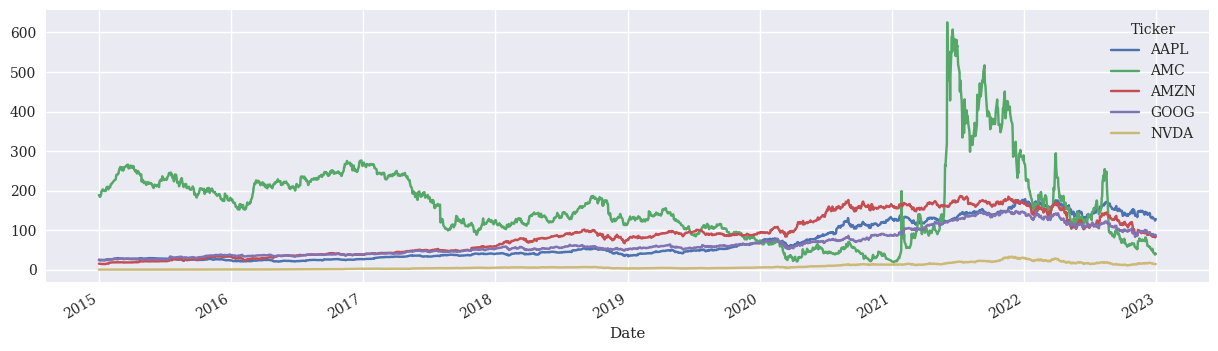

In [50]:
tickers = ['AAPl', 'AMC', 'GOOG', 'AMZN', 'NVDA']
data = yf.download(tickers, start="2015-01-01", end="2022-12-31")['Close']  # We use the data from 2015 to 2023 to find the optimal weights

data.plot(figsize=(15,4))
data.head()

Here, I have plotted the returns of each stock

Ticker,AAPL,AMC,AMZN,GOOG,NVDA
Date,,,,,
2015-01-05,-0.028172,-0.025751,-0.020517,-0.020846,-0.016890
2015-01-06,0.000094,0.008010,-0.022833,-0.023177,-0.030319
2015-01-07,0.014022,0.016289,0.010600,-0.001713,-0.002605
2015-01-08,0.038422,0.009773,0.006836,0.003153,0.037617
2015-01-09,0.001072,0.040264,-0.011749,-0.012951,0.004028


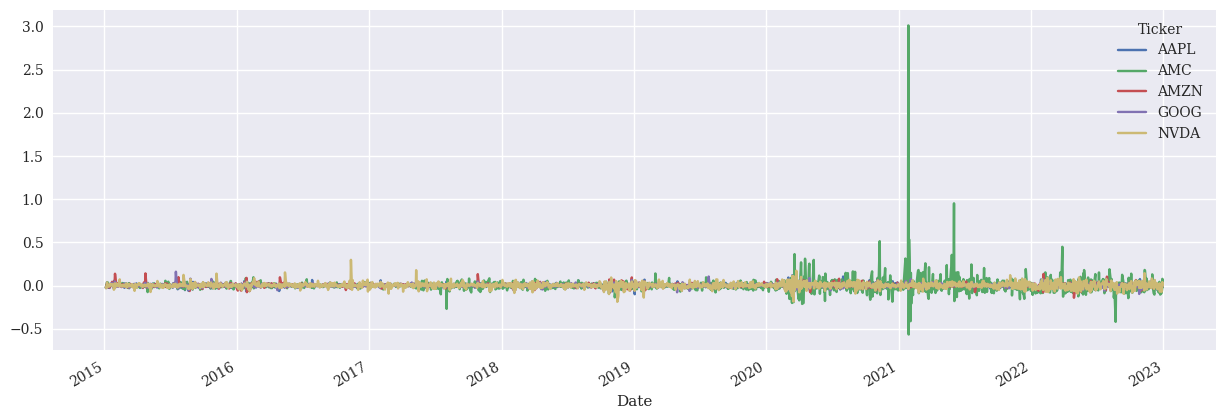

In [51]:
returns = data.pct_change().dropna()

returns.plot(figsize=(15,5))
returns.head()

The Expected returns is given by: 
Ticker
AAPL    0.253259
AMC     0.471584
AMZN    0.267343
GOOG    0.192895
NVDA    0.541968
dtype: float64 

The Covariance matrix is given by: 
Ticker      AAPL       AMC      AMZN      GOOG      NVDA
Ticker                                                  
AAPL    0.089689  0.051204  0.058280  0.054082  0.083761
AMC     0.051204  2.095102  0.047052  0.042815  0.081137
AMZN    0.058280  0.047052  0.110866  0.062589  0.085433
GOOG    0.054082  0.042815  0.062589  0.080307  0.077377
NVDA    0.083761  0.081137  0.085433  0.077377  0.231402 



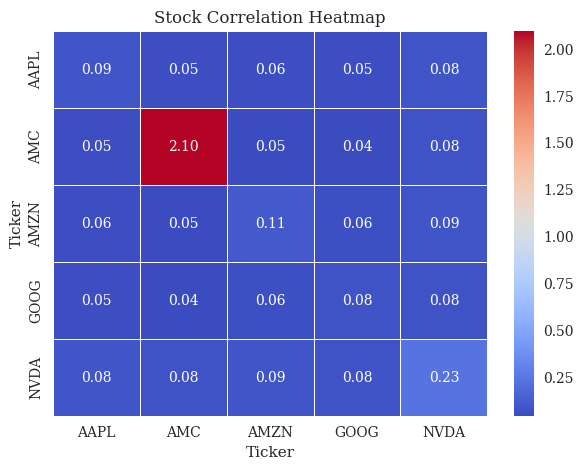

In [52]:
mu = returns.mean() * 252
sigma = returns.cov() * 252
print("The Expected returns is given by: ")
print(mu,'\n')
print("The Covariance matrix is given by: ")
print(sigma,'\n')
plt.figure(figsize=(7, 5))
sns.heatmap(sigma, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Stock Correlation Heatmap")
plt.show()

We could see through the high volitality of the `AMC` stock it has a high volitality associated with it 

## 3. Mordern Portfolio theory

Here, we find the way we should allocate funds to each stock such that the returns is maximized and the risk is minimized

In [53]:
mu.mean()

0.3454097976382465

In [54]:
n = len(mu)
w = cp.Variable(n)

risk = cp.quad_form(w, sigma)
constraints = [
    cp.sum(w) == 1,
    mu.values @ w >= 0.12
]

prob = cp.Problem(cp.Minimize(risk), constraints)
prob.solve()

print("Optimal Weights:", w.value)

Optimal Weights: [ 0.40986256  0.0113143   0.16640709  0.50919988 -0.09678384]


In [55]:
expected_return = mu @ w.value
portfolio_variance = w.value.T @ sigma @ w.value
portfolio_std = np.sqrt(portfolio_variance)

print("Expected Portfolio Return:", round(expected_return, 4))
print("Portfolio Risk (Std Dev):", round(portfolio_std, 4))

Expected Portfolio Return: 0.1994
Portfolio Risk (Std Dev): 0.2578


## 3. Backtesting

[*********************100%***********************]  5 of 5 completed


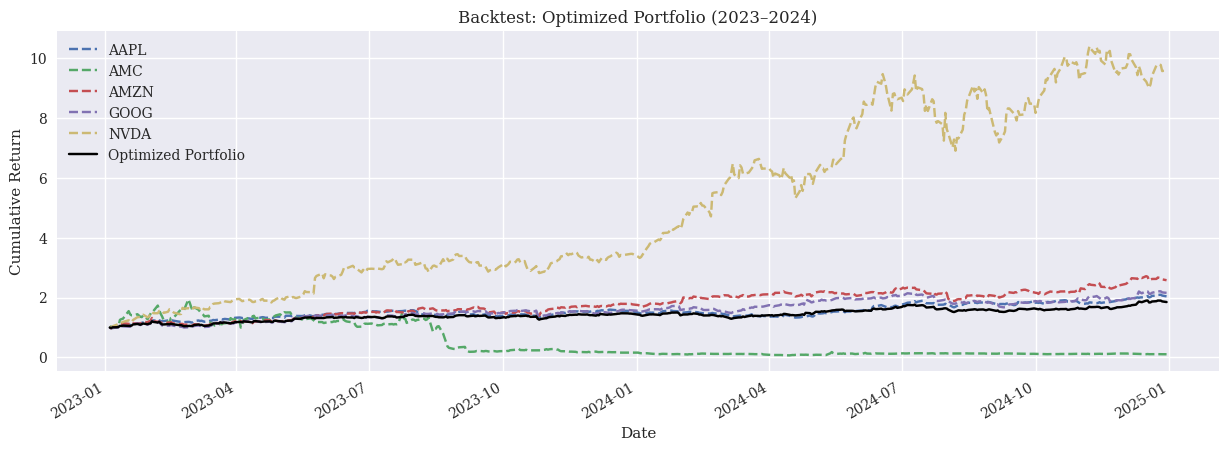

In [ ]:
future_data = yf.download(tickers, start="2023-01-01", end="2024-12-31")['Close']  # Here, we see how our portfolio works in future timelines
future_returns = future_data.pct_change().dropna()

opt_weights = w.value
optimized_portfolio_returns = future_returns @ opt_weights
cumulative_optimized_portfolio = (1 + optimized_portfolio_returns).cumprod()
cummulative_future = (1 + future_returns).cumprod()

# Plot
cummulative_future.plot(label='Actual Stocks',linestyle='--',figsize=(15, 5))
cumulative_optimized_portfolio.plot(label='Optimized Portfolio', color='Black',figsize=(15, 5))
plt.title('Backtest: Optimized Portfolio (2023–2024)')
plt.ylabel('Cumulative Return')
plt.xlabel('Date')
plt.grid(True)
plt.legend()
plt.show()

Here, we could see that the `NVDA` stock grew exponentially and `AMC` stock fell dramatically. But, we could see that our portfolio accounts for this risk and shows steady growth

### 3.1 Comparing with an equally allocated Portfolio and S&P 500

[*********************100%***********************]  1 of 1 completed


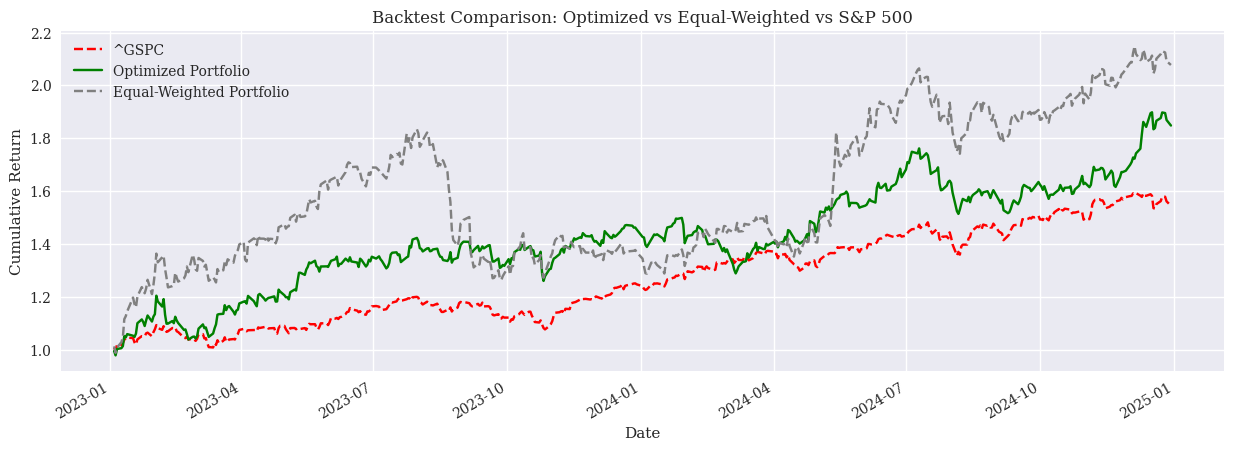

In [64]:
# Equal-weighted return
equal_weights = np.ones(n) / n
equal_portfolio_returns = future_returns @ equal_weights
equal_cumulative = (1 + equal_portfolio_returns).cumprod()

SNP_data = yf.download('^GSPC', start="2023-01-01", end="2024-12-31")['Close']  # Here, we see how our portfolio works in future timelines
SNP_returns = SNP_data.pct_change().dropna()
SNP_cum_returns = (1 + SNP_returns).cumprod()

# Plot both

SNP_cum_returns['2023-01-04':'2025-01-01'].plot(label='S&P 500 Benchmark',color='red',linestyle='--',figsize=(15, 5))
cumulative_optimized_portfolio['2023-01-04':'2025-01-01'].plot(label='Optimized Portfolio', color='green',figsize=(15, 5))
equal_cumulative['2023-01-04':'2025-01-01'].plot(label='Equal-Weighted Portfolio', color='gray', linestyle='--',figsize=(15, 5))
plt.title('Backtest Comparison: Optimized vs Equal-Weighted vs S&P 500')
plt.ylabel('Cumulative Return')
plt.xlabel('Date')
plt.grid(True)
plt.legend()
plt.show()


An equal-weighted portfolio gives the same importance to all assets, regardless of their risk, which can lead to more volatility if some stocks are highly risky or poorly diversified.

In contrast, my Markowitz-optimized portfolio adjusts weights based on both risk and return, reducing exposure to riskier assets. This results in smoother performance and more stable growth, as seen in the backtest, without sacrificing returns.

## 4. Performance Metrics

In [58]:
def EvaluationMetrics(portfolio_returns: pd.Series, risk_free_rate: float = 0.0, confidence_level: float = 0.95) -> pd.DataFrame:
    
    returns = portfolio_returns.dropna()
    trading_days = 252

    cumulative_return = (1 + returns).prod() - 1

    total_days = len(returns)
    years = total_days / trading_days
    cagr = (1 + cumulative_return) ** (1 / years) - 1

    annual_volatility = returns.std() * np.sqrt(trading_days)

    daily_rf = risk_free_rate / trading_days
    excess_returns = returns - daily_rf
    sharpe_ratio = excess_returns.mean() / returns.std() * np.sqrt(trading_days)

    downside_returns = returns[returns < 0]
    if len(downside_returns) > 0:
        sortino_ratio = excess_returns.mean() / downside_returns.std() * np.sqrt(trading_days)
    else:
        sortino_ratio = np.nan  # Avoid division by zero

    cumulative = (1 + returns).cumprod()
    rolling_max = cumulative.cummax()
    drawdown = cumulative / rolling_max - 1
    max_drawdown = drawdown.min()

    var = np.percentile(returns, (1 - confidence_level) * 100)
    cvar = returns[returns <= var].mean()

    metrics = {
        'Cumulative Return': cumulative_return,
        'Annualized Return (CAGR)': cagr,
        'Annualized Volatility': annual_volatility,
        'Sharpe Ratio': sharpe_ratio,
        'Sortino Ratio': sortino_ratio,
        f'CVaR ({int(confidence_level*100)}%)': cvar,
        'Max Drawdown': max_drawdown,
    }

    return pd.DataFrame(metrics, index=[0]).T.rename(columns={0: 'Value'})


In [ ]:
EvaluationMetrics(optimized_portfolio_returns)

,Value
Cumulative Return,0.848335
Annualized Return (CAGR),0.362880
Annualized Volatility,0.221670
Sharpe Ratio,1.508222
Sortino Ratio,2.208779
CVaR (95%),-0.030399
Max Drawdown,-0.140713


In [60]:
EvaluationMetrics(equal_portfolio_returns)

,Value
Cumulative Return,1.077588
Annualized Return (CAGR),0.445606
Annualized Volatility,0.319379
Sharpe Ratio,1.312294
Sortino Ratio,2.071596
CVaR (95%),-0.039743
Max Drawdown,-0.311029


In [73]:
SNP_series = SNP_returns['^GSPC']
EvaluationMetrics(SNP_series)

,Value
Cumulative Return,0.544645
Annualized Return (CAGR),0.245001
Annualized Volatility,0.128753
Sharpe Ratio,1.767012
Sortino Ratio,2.583643
CVaR (95%),-0.017440
Max Drawdown,-0.102766


## Summary of Comparison Results

| Metric            | Optimized Portfolio | Equal-Weighted | S\&P 500 |
| ----------------- | ------------------- | -------------- | -------- |
| Cumulative Return | 84.8%               | 107.7%         | 54.4%    |
| Annualized Return | 36.3%               | 44.6%          | 24.5%    |
| Sharpe Ratio      | 1.51                | 1.31           | 1.2     |
| Max Drawdown      | -14.1%              | -31.1%         | -10.2%   |
| CVaR (95%)        | -3.0%               | -3.9%          | -1.7%    |


While the equally weighted portfolio achieved slightly higher total and annualized returns, it did so with significantly higher volatility and risk.

In contrast, the optimized portfolio achieved a better Sharpe and Sortino ratio, indicating superior risk-adjusted performance. It also had less severe drawdowns and lower tail risk (CVaR), making it a much safer and more stable choice for risk-conscious investors.Compared to the S&P 500, my portfolio outperforms in both return and Sharpe ratio, while still maintaining comparable drawdown and CVaR.